## Titanic - Machine Learning from Disaster

### 1. Загрузка данных

In [1]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import os
import random
from pathlib import Path

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
# Опрелим устройство для вычислений: ГПУ/ЦПУ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
SEED = 42

# Зафиксируем сид для воспроизводимости эесперимента
def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

In [5]:
seed_everything(SEED)

In [ ]:
# Пути к данным и папке для сабмитов
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebook":
    PROJECT_DIR = PROJECT_DIR.parent
elif PROJECT_DIR.name != "titanic":
    PROJECT_DIR = PROJECT_DIR / "titanic"

DATA_DIR = PROJECT_DIR / 'data' / 'raw'
SUBMISSION_DIR = PROJECT_DIR / 'submissions'

SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / 'train.csv'
test_path = DATA_DIR / 'test.csv'

In [ ]:
# Загрузим обучающую, тестовую выборки и пример файла сабмита
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

### 2. Первичный осмотр

In [8]:
# Смотрим размер обучающей и тестовой выборок
train.shape, test.shape

((891, 12), (418, 11))

In [9]:
# Быстро проверяем первые строки в train
train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [10]:
# Смотрим типы данных и пропуски в train
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
# Быстро проверяем первые строки в test
test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [12]:
# Смотрим типы данных и пропуски в test
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [13]:
# Получим базовые статистики по всем колонкам
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### 3. EDA

На этапе EDA посмотрим:
- распределение целевой переменной;
- структуру пропусков в train и test;
- связь отдельных признаков с выживаемостью;
- распределения числовых признаков и возможные выбросы;
- базовые корреляции между числовыми признаками.

In [14]:
# Посмотрим распределение таргета в абсолютных значениях
train.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
# То же в долях
train.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [16]:
# Анализируем пропуски в train
missing_train_table = pd.DataFrame({
    'missing_count': train.isna().sum(),
    'missing_percent': train.isna().mean()
}).sort_values(by='missing_count', ascending=False)

# Оставляем только признаки, где действительно есть пропуски
missing_train_table = missing_train_table[missing_train_table['missing_count'] > 0]

missing_train_table

,missing_count,missing_percent
Cabin,687,0.771044
Age,177,0.198653
Embarked,2,0.002245


In [17]:
# Аналогично анализируем пропуски в test
missing_test_table = pd.DataFrame({
    'missing_count': test.isna().sum(),
    'missing_percent': test.isna().mean()
}).sort_values(by='missing_count', ascending=False)

missing_test_table = missing_test_table[missing_test_table['missing_count'] > 0]

missing_test_table

,missing_count,missing_percent
Cabin,327,0.782297
Age,86,0.205742
Fare,1,0.002392


In [18]:
# Смотрим среднюю выживаемость по полу, классу, месту посадки
train.groupby(['Sex'])['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [19]:
train.groupby(['Pclass'])['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [20]:
train.groupby(['Embarked'])['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

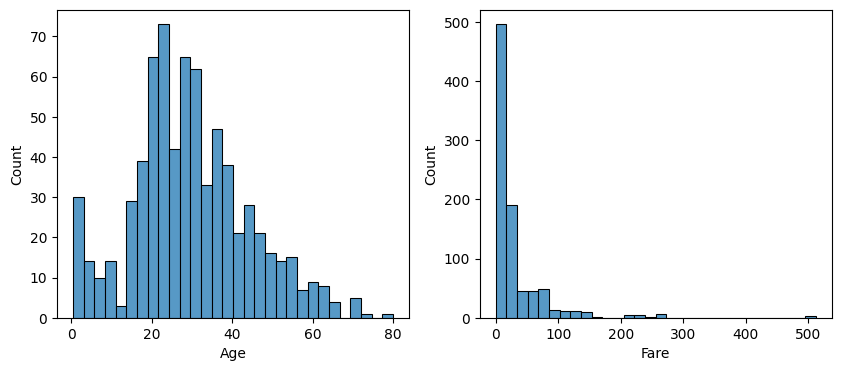

In [21]:
# Смотрим распределения возраста и стоимости билета
plt.figure(figsize=(10,4))

ax1 = plt.subplot(121)
sns.histplot(train.Age, bins=30, ax=ax1)

ax2 = plt.subplot(122)
sns.histplot(train.Fare, bins=30, ax=ax2)

plt.show()

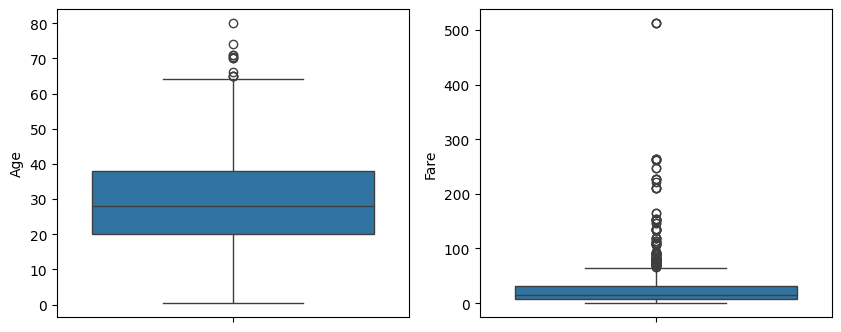

In [22]:
# Отдельно проверяем наличие выбросов в Age и Fare
plt.figure(figsize=(10,4))

ax1 = plt.subplot(121)
sns.boxplot(train.Age, ax=ax1)

ax2 = plt.subplot(122)
sns.boxplot(train.Fare, ax=ax2)

plt.show()

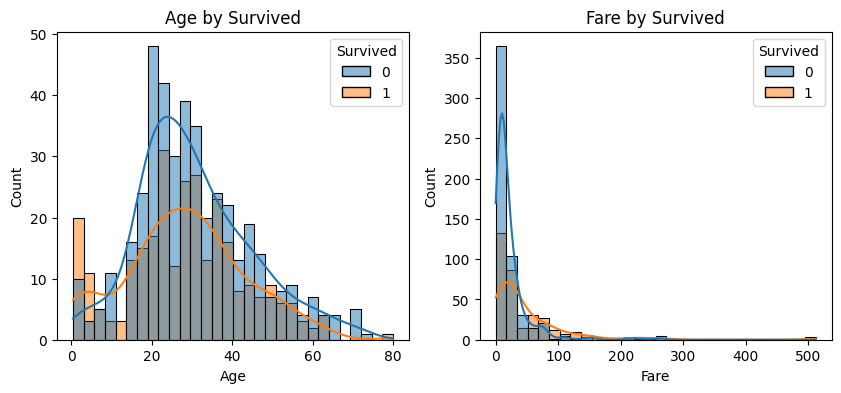

In [23]:
# Смотрим, как распределения Age и Fare связаны с выживаемостью
plt.figure(figsize=(10,4))

ax1 = plt.subplot(121)
sns.histplot(data=train, x='Age', hue='Survived', kde=True, bins=30, ax=ax1)
ax1.set_title('Age by Survived')

ax2 = plt.subplot(122)
sns.histplot(data=train, x='Fare', hue='Survived', kde=True, bins=30, ax=ax2)
ax2.set_title('Fare by Survived')

plt.show()

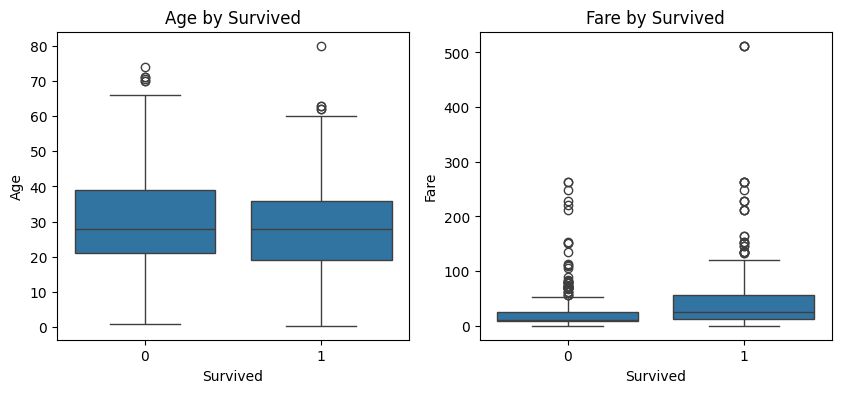

In [24]:
# Сравниваем Age и Fare между классами Survived = 0 и Survived = 1
plt.figure(figsize=(10,4))

ax1 = plt.subplot(121)
sns.boxplot(data=train, x='Survived', y='Age', ax=ax1)
ax1.set_title('Age by Survived')

ax2 = plt.subplot(122)
sns.boxplot(data=train, x='Survived', y='Fare', ax=ax2)
ax2.set_title('Fare by Survived')

plt.show()

In [25]:
# Посмотрим уникальные значения и пропуски в текстовых признаках,
# которые потенциально можно использовать для последующего feature engineering
train.Name.nunique(), train.Name.isna().sum().item()

(891, 0)

In [26]:
train.Ticket.nunique(), train.Ticket.isna().sum().item()

(681, 0)

In [27]:
train.Cabin.nunique(), train.Cabin.isna().sum().item()

(147, 687)

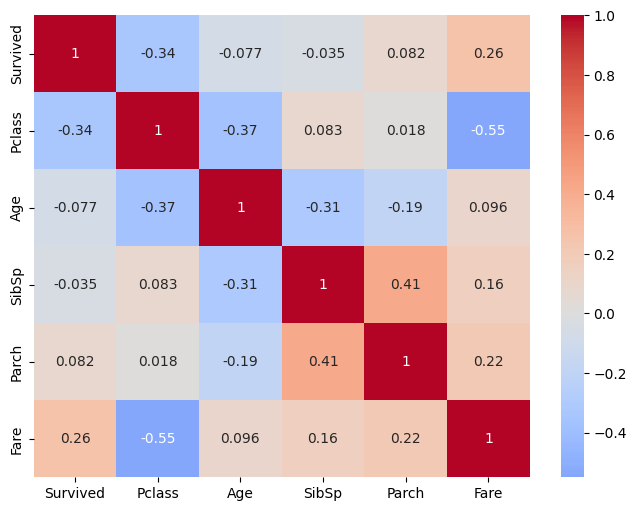

In [28]:
# Строим матрицу корреляций
cols_for_corr = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

### 4. Бейзлайн препроцессинг

In [29]:
# Базовый набор признаков для первого pipeline
features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Sex', 'Embarked']
X = train[features]
y = train.Survived
X_test = test[features].copy()

In [30]:
#  Разделим признаки на числовые и категориальные
numerical_features = features[:4]
categorical_features = features[4:]

In [31]:
# Сделаем hold-out cv (только для первого бейзлайна)
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=0.2, 
                                                  random_state=42,
                                                  shuffle=True,
                                                  stratify=y)

In [32]:
# Для числовых признаков: заполним пропуски медианой и стандартизируем
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Для категориальных признаков: заполним модой и OHE
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [33]:
# Обе ветки преобразований засунем в ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [34]:
# Строим итоговый пайплайн из препроцессинга и логрега
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

### 5. Первичный бейзлайн на отложенной выборке

In [35]:
# Обучим бейзлайн модель
pipeline.fit(X_train, y_train)
# Сделам предсказания на отложенной выборке
y_val_pred = pipeline.predict(X_val)

In [36]:
# Посчитаем и выведем базовые метрики качества
accuracy = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'F1: {f1:.4f}')

Accuracy: 0.7989
F1: 0.7188


In [37]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



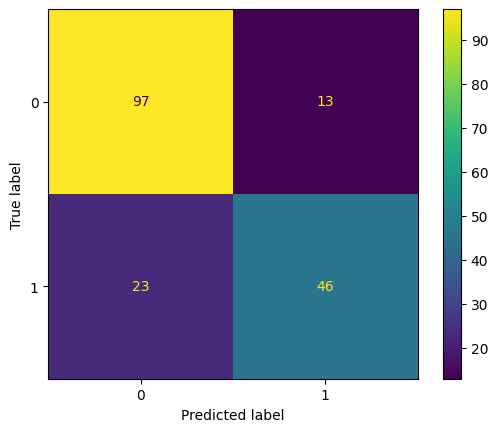

In [38]:
# Посмотрим матрицу ошибок для бейзлайна
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm).plot()
plt.show()

In [39]:
# Извлечем коэффициенты регрессии
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = pipeline.named_steps['model'].coef_[0]

In [40]:
coef_table = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
}).sort_values('coef', ascending=False).reset_index(drop=True)
coef_table

,feature,coef
0,cat__Embarked_Q,0.228675
1,num__Fare,0.174708
2,num__Parch,-0.069937
3,num__SibSp,-0.260728
4,cat__Embarked_S,-0.438453
5,num__Age,-0.468895
6,cat__Pclass_2,-0.734868
7,cat__Pclass_3,-1.919663
8,cat__Sex_male,-2.529833


### 6. Технический сабмит

In [41]:
# Делаем первый технический submit, чтобы проверить весь пайплайн целиком
# и правильность формата
y_pred = pipeline.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test.PassengerId,
    'Survived': y_pred
})

In [42]:
submission.to_csv(SUBMISSION_DIR / 'submission_0.csv', index=False)

Получили `LB-score` = 0.77272

### 7. Кросс-валидация

После первого бейзлайна на hold-out выборке переходим к оценке качества через Stratified K-Fold CV.

В дальнейшем именно этот протокол валидации будет использоваться для сравнения всех основных моделей.

In [43]:
# Создаем объект стратифицированной 5-fold кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [44]:
def run_cv_pipeline(pipeline, X, y, X_test, cv, threshold=0.5):
    # Здесь будем хранить OOF-вероятности для трейна
    oof_proba = np.zeros(X.shape[0], dtype=np.float32)
    # Сюда будем складывать тестовые вероятности с каждого фолда
    test_fold_probs = []
    # Списки для сбора метрик по фолдам
    fold_accuracy = []
    fold_f1 = []
    fold_auc = []

    # Проходим по всем фолдам
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        # Формируем train/val части текущего фолда
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        # Клонируем pipeline, чтобы каждый фолд обучался независимо
        model = clone(pipeline)
        model.fit(X_train_fold, y_train_fold)

        # Получим вероятности и бинарные предсказания на валидации
        val_proba = model.predict_proba(X_val_fold)[:, 1]
        val_pred = (val_proba >= threshold).astype(int) # для метрик на фолде
        
        # Получим вероятности на тесте
        test_proba = model.predict_proba(X_test)[:, 1]
        test_fold_probs.append(test_proba)
        
        # Записываем OOF-предсказания на соответствующие позиции
        oof_proba[val_idx] = val_proba        

        # Считаем метрики на текущем фолде
        fold_accuracy.append(accuracy_score(y_val_fold, val_pred))
        fold_f1.append(f1_score(y_val_fold, val_pred))
        fold_auc.append(roc_auc_score(y_val_fold, val_proba))
    
    # Получаем итоговые OOF-классы по заданному порогу
    oof_pred = (oof_proba >= threshold).astype(int)

    # Усредняем вероятности на тесте по всем фолдам
    mean_test_proba = np.mean(test_fold_probs, axis=0)
    test_pred = (mean_test_proba >= threshold).astype(int)

    results = {
        'fold_accuracy': fold_accuracy,
        'fold_f1': fold_f1,
        'fold_auc': fold_auc,
        'oof_proba': oof_proba,
        'oof_pred': oof_pred,
        'mean_test_proba': mean_test_proba,
        'test_pred': test_pred,
        'oof_accuracy': accuracy_score(y, oof_pred),
        'oof_f1': f1_score(y, oof_pred),
        'oof_auc': roc_auc_score(y, oof_proba),
        'mean_fold_accuracy': np.mean(fold_accuracy),
        'std_fold_accuracy': np.std(fold_accuracy),
        'mean_fold_f1': np.mean(fold_f1),
        'std_fold_f1': np.std(fold_f1),
        'mean_fold_auc': np.mean(fold_auc),
        'std_fold_auc': np.std(fold_auc),
    }
    
    return results 

In [45]:
# Отдельная функция кросс-валидации для CatBoost,
# так как он работает с категориальными признаками иначе, чем sklearn pipeline
def run_cv_catboost(model_factory, X, y, X_test, cv, 
                    numerical_features, categorical_features, 
                    threshold=0.5):
    
    oof_proba = np.zeros(len(X), dtype=np.float32)
    test_fold_probs = []

    fold_accuracy = []
    fold_f1 = []
    fold_auc = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train_fold = X.iloc[train_idx].copy()
        X_val_fold = X.iloc[val_idx].copy()
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        X_test_fold = X_test.copy()

        # Все статистики для заполнения пропусков считаем только по train fold
        train_median = X_train_fold[numerical_features].median()
        train_mode = X_train_fold[categorical_features].mode().iloc[0]

        X_train_fold[numerical_features] = X_train_fold[numerical_features].fillna(train_median)
        X_val_fold[numerical_features] = X_val_fold[numerical_features].fillna(train_median)
        X_test_fold[numerical_features] = X_test_fold[numerical_features].fillna(train_median)

        X_train_fold[categorical_features] = X_train_fold[categorical_features].fillna(train_mode)
        X_val_fold[categorical_features] = X_val_fold[categorical_features].fillna(train_mode)
        X_test_fold[categorical_features] = X_test_fold[categorical_features].fillna(train_mode)

        # Приводим категориальные признаки к строковому типу для CatBoost
        for col in categorical_features:
            X_train_fold[col] = X_train_fold[col].astype(str)
            X_val_fold[col] = X_val_fold[col].astype(str)
            X_test_fold[col] = X_test_fold[col].astype(str)

        model = model_factory()
        model.fit(X_train_fold, y_train_fold)

        val_proba = model.predict_proba(X_val_fold)[:, 1]
        val_pred = (val_proba >= threshold).astype(int)

        test_proba = model.predict_proba(X_test_fold)[:, 1]
        test_fold_probs.append(test_proba)

        oof_proba[val_idx] = val_proba

        acc = accuracy_score(y_val_fold, val_pred)
        f1 = f1_score(y_val_fold, val_pred)
        auc = roc_auc_score(y_val_fold, val_proba)

        fold_accuracy.append(acc)
        fold_f1.append(f1)
        fold_auc.append(auc)

    oof_pred = (oof_proba >= threshold).astype(int)
    mean_test_proba = np.mean(test_fold_probs, axis=0)
    test_pred = (mean_test_proba >= threshold).astype(int)

    return {
        'fold_accuracy': fold_accuracy,
        'fold_f1': fold_f1,
        'fold_auc': fold_auc,
        'oof_proba': oof_proba,
        'oof_pred': oof_pred,
        'mean_test_proba': mean_test_proba,
        'test_pred': test_pred,
        'oof_accuracy': accuracy_score(y, oof_pred),
        'oof_f1': f1_score(y, oof_pred),
        'oof_auc': roc_auc_score(y, oof_proba),
        'mean_fold_accuracy': np.mean(fold_accuracy),
        'std_fold_accuracy': np.std(fold_accuracy),
        'mean_fold_f1': np.mean(fold_f1),
        'std_fold_f1': np.std(fold_f1),
        'mean_fold_auc': np.mean(fold_auc),
        'std_fold_auc': np.std(fold_auc),
    }

In [46]:
# Прогоняем бейзлайн через 5-fold stratified CV
results = run_cv_pipeline(pipeline, X, y, X_test, cv)

In [47]:
print('CV results:')
print(f"Accuracy: {results['mean_fold_accuracy']:.4f} ± {results['std_fold_accuracy']:.4f}")
print(f"F1:       {results['mean_fold_f1']:.4f} ± {results['std_fold_f1']:.4f}")
print(f"ROC AUC:  {results['mean_fold_auc']:.4f} ± {results['std_fold_auc']:.4f}")
print()
print('OOF results:')
print(f"OOF Accuracy: {results['oof_accuracy']:.4f}")
print(f"OOF F1:       {results['oof_f1']:.4f}")
print(f"OOF ROC AUC:  {results['oof_auc']:.4f}")

CV results:
Accuracy: 0.8036 ± 0.0145
F1:       0.7323 ± 0.0235
ROC AUC:  0.8511 ± 0.0222

OOF results:
OOF Accuracy: 0.8036
OOF F1:       0.7328
OOF ROC AUC:  0.8500


### 8. Сравнение моделей

После построения бейзлайна переходим к систематическому сравнению нескольких семейств моделей.

Для удобства будем:
- сохранять все эксперименты в общую таблицу;
- отдельно хранить лучшую модель внутри каждого семейства;
- сравнивать модели по mean `CV Accuracy`, а при близких значениях — по `F1` и `ROC AUC`.

In [48]:
# Перед повторным прогоном раздела заново инициализируем реестр экспериментов,
# чтобы не накапливать дубли и старые лучшие результаты
all_experiments = []
best_family_models = {}

In [ ]:
# Инфраструктура для сравнения моделей

# Сравнение двух кандидатов:
# 1) по mean_fold_accuracy
# 2) если почти равны — по mean_fold_f1
# 3) если почти равны — по mean_fold_auc
def is_better_result(new_results, old_results, tol=1e-6):
    """
    Сравнение двух кандидатов:
        1) по mean_fold_accuracy
        2) если почти равны — по mean_fold_f1
        3) если почти равны — по mean_fold_auc
    """
    if old_results is None:
        return True
    
    if new_results['mean_fold_accuracy'] > old_results['mean_fold_accuracy'] + tol:
        return True
    
    if np.isclose(new_results['mean_fold_accuracy'], old_results['mean_fold_accuracy'], atol=tol):
        if new_results['mean_fold_f1'] > old_results['mean_fold_f1'] + tol:
            return True
        
        if np.isclose(new_results['mean_fold_f1'], old_results['mean_fold_f1'], atol=tol):
            if new_results['mean_fold_auc'] > old_results['mean_fold_auc'] + tol:
                return True
    
    return False


def register_model_result(family_name, model_name, params, results):
    """
    1) Добавляет строку в общую таблицу экспериментов
    2) Обновляет лучшую модель в семействе
    """
    global all_experiments, best_family_models
    
    row = {
        'family': family_name,
        'model_name': model_name,
        'params': params,
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'std_fold_f1': results['std_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'std_fold_auc': results['std_fold_auc'],
        'oof_auc': results['oof_auc'],
    }
    all_experiments.append(row)

    # Если модель лучшая внутри своего семейства, 
    # сохраняем и метрики, и предсказания
    old_entry = best_family_models.get(family_name)

    if old_entry is None or is_better_result(results, old_entry):
        best_family_models[family_name] = {
            'family': family_name,
            'model_name': model_name,
            'params': params,
            'mean_fold_accuracy': results['mean_fold_accuracy'],
            'std_fold_accuracy': results['std_fold_accuracy'],
            'oof_accuracy': results['oof_accuracy'],
            'mean_fold_f1': results['mean_fold_f1'],
            'std_fold_f1': results['std_fold_f1'],
            'oof_f1': results['oof_f1'],
            'mean_fold_auc': results['mean_fold_auc'],
            'std_fold_auc': results['std_fold_auc'],
            'oof_auc': results['oof_auc'],
            'oof_proba': results['oof_proba'].copy(),
            'oof_pred': results['oof_pred'].copy(),
            'mean_test_proba': results['mean_test_proba'].copy(),
            'test_pred': results['test_pred'].copy(),
        }


def best_models_table(best_models_dict):
    """Собирает таблицу лучших моделей по каждому семейству."""
    rows = []
    for family_name, entry in best_models_dict.items():
        rows.append({
            'family': family_name,
            'model_name': entry['model_name'],
            'params': entry['params'],
            'mean_fold_accuracy': entry['mean_fold_accuracy'],
            'std_fold_accuracy': entry['std_fold_accuracy'],
            'oof_accuracy': entry['oof_accuracy'],
            'mean_fold_f1': entry['mean_fold_f1'],
            'oof_f1': entry['oof_f1'],
            'mean_fold_auc': entry['mean_fold_auc'],
            'oof_auc': entry['oof_auc'],
        })
    return pd.DataFrame(rows).sort_values(
        by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
        ascending=False
    ).reset_index(drop=True)


# Возвращает полную таблицу всех экспериментов, отсортированную по качеству
def all_experiments_table():
    """Возвращает полную таблицу всех экспериментов, отсортированную по качеству."""
    return pd.DataFrame(all_experiments).sort_values(
        by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
        ascending=False
    ).reset_index(drop=True)


# Сохраняет предсказания в формате Kaggle submission
def save_submission(preds, filename):
    """Сохраняет предсказания в формате Kaggle submission."""
    submission = pd.DataFrame({
        'PassengerId': test['PassengerId'],
        'Survived': preds.astype(int)
    })
    submission.to_csv(SUBMISSION_DIR / filename, index=False)
    return submission

#### 8.1 Линейные модели

In [50]:
# Сравниваем несколько вариантов логрег с разными типами регуляризации
models = {
    'LogRegNoPenalty': LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42),
    'LogRegL1': LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=1000, random_state=42),
    'LogRegL2': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    'LogRegEN': LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=1.0, solver='saga', max_iter=1000, random_state=42),
}

In [51]:
linear_results_table = pd.DataFrame(
    columns=['model_name', 'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
             'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']
)

In [52]:
# Для линейных моделей и KNN используем масштабирование числовых признаков
def pipeline_constructor_linear_knn(model):
    numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    return pipeline

In [53]:
for model_name, model in models.items():    
    pipeline = pipeline_constructor_linear_knn(model)
    results = run_cv_pipeline(pipeline, X, y, X_test, cv)

    linear_results_table.loc[len(linear_results_table)] = {
        'model_name': model_name,
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'oof_auc': results['oof_auc'],
    }

    # Регистрируем результат, чтобы затем выбрать лучшую модель семейства
    register_model_result(
        family_name='linear',
        model_name=model_name,
        params=model.get_params(),
        results=results
    )

linear_results_table = linear_results_table.sort_values(by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'], ascending=False).reset_index(drop=True)

c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

In [54]:
linear_results_table

,model_name,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,LogRegL2,0.803603,0.014478,0.803591,0.732314,0.732824,0.851083,0.849980
1,LogRegEN,0.801362,0.016308,0.801347,0.730179,0.730594,0.851215,0.850278
2,LogRegL1,0.800239,0.017446,0.800224,0.729127,0.729483,0.851269,0.850512
3,LogRegNoPenalty,0.795757,0.015817,0.795735,0.725438,0.725904,0.851506,0.850219


#### 8.2 KNN

In [55]:
# Делаем умеренный перебор по основным гиперпараметрам KNN
n_neighbors = [3, 5, 7, 11, 15, 21]
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan']

In [56]:
knn_results_table = pd.DataFrame(
    columns=['n_neighbors', 'weights', 'metric',
             'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
             'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']
)

In [57]:
for n in n_neighbors:
    for w in weights:
        for m in metric:
            model = KNeighborsClassifier(n_neighbors=n, weights=w, metric=m)
            pipeline = pipeline_constructor_linear_knn(model)
            results = run_cv_pipeline(pipeline, X, y, X_test, cv)

            knn_results_table.loc[len(knn_results_table)] = {
                'n_neighbors': n,
                'weights': w,
                'metric': m,
                'mean_fold_accuracy': results['mean_fold_accuracy'],
                'std_fold_accuracy': results['std_fold_accuracy'],
                'oof_accuracy': results['oof_accuracy'],
                'mean_fold_f1': results['mean_fold_f1'],
                'oof_f1': results['oof_f1'],
                'mean_fold_auc': results['mean_fold_auc'],
                'oof_auc': results['oof_auc'],
            }

            register_model_result(
                family_name='knn',
                model_name='KNN',
                params={
                    'n_neighbors': n,
                    'weights': w,
                    'metric': m
                },
                results=results
            )

knn_results_table  = knn_results_table.sort_values(by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'], ascending=False).reset_index(drop=True)

In [58]:
knn_results_table.head()

,n_neighbors,weights,metric,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,5,uniform,manhattan,0.812554,0.029306,0.812570,0.746387,0.746586,0.849076,0.849405
1,21,uniform,manhattan,0.811449,0.016103,0.811448,0.734355,0.734177,0.864198,0.863833
2,15,uniform,manhattan,0.805825,0.010605,0.805836,0.729174,0.729264,0.856560,0.856049
3,7,uniform,manhattan,0.803572,0.017960,0.803591,0.732209,0.732824,0.855457,0.855721
4,11,uniform,manhattan,0.802486,0.009281,0.802469,0.728147,0.728395,0.853625,0.854235


#### 8.3 Деревья решений и Случайный лес

In [59]:
# Делаем умеренный перебор по основным гиперпараметрам дерева решений
criterion = ['gini', 'entropy']
max_depth = [3, 5, 7, 10, None]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
class_weight = [None, 'balanced']

In [60]:
decision_tree_results_table = pd.DataFrame(
    columns=['criterion', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'class_weight',
             'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
             'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']
)

In [61]:
# Для деревянных моделей масштабирование числовых признаков не требуется
def pipeline_constructor_tree(model):
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    return pipeline

In [62]:
for cr in criterion:
    for depth in max_depth:
        for split in min_samples_split:
            for leaf in min_samples_leaf:
                for cw in class_weight:    
                    model = DecisionTreeClassifier(
                            criterion=cr,
                            max_depth=depth,
                            min_samples_split=split,
                            min_samples_leaf=leaf,
                            class_weight=cw,
                            random_state=42
                    )
                    pipeline = pipeline_constructor_tree(model)
                    results = run_cv_pipeline(pipeline, X, y, X_test, cv)

                    decision_tree_results_table.loc[len(decision_tree_results_table)] = {
                        'criterion': cr,
                        'max_depth': depth,
                        'min_samples_split': split,
                        'min_samples_leaf': leaf,
                        'class_weight': cw,
                        'mean_fold_accuracy': results['mean_fold_accuracy'],
                        'std_fold_accuracy': results['std_fold_accuracy'],
                        'oof_accuracy': results['oof_accuracy'],
                        'mean_fold_f1': results['mean_fold_f1'],
                        'oof_f1': results['oof_f1'],
                        'mean_fold_auc': results['mean_fold_auc'],
                        'oof_auc': results['oof_auc'],
                    }

                    register_model_result(
                        family_name='tree',
                        model_name='DecisionTree',
                        params={
                            'criterion': cr,
                            'max_depth': depth,
                            'min_samples_split': split,
                            'min_samples_leaf': leaf,
                            'class_weight': cw,
                        },
                        results=results
                    )

decision_tree_results_table = decision_tree_results_table.sort_values(by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'], ascending=False).reset_index(drop=True)

In [63]:
decision_tree_results_table.head()

,criterion,max_depth,min_samples_split,min_samples_leaf,class_weight,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,entropy,7,10,4,None,0.829377,0.026170,0.829405,0.759114,0.75873,0.853143,0.852499
1,gini,3,2,4,None,0.827148,0.014521,0.827160,0.759694,0.76087,0.864764,0.854531
2,gini,3,5,4,None,0.827148,0.014521,0.827160,0.759694,0.76087,0.864764,0.854531
3,gini,3,10,4,None,0.827148,0.014521,0.827160,0.759694,0.76087,0.864764,0.854531
4,gini,3,2,2,None,0.827148,0.014521,0.827160,0.759694,0.76087,0.863578,0.853127


In [64]:
# Делаем умеренный перебор по основным гиперпараметрам Случайного леса
n_estimators = [100, 300]
max_depth = [3, 5, 7, None]
min_samples_split = [2, 10]
min_samples_leaf = [1, 2, 4]
max_features = ['sqrt', 'log2', None]
class_weight = [None, 'balanced']

In [65]:
random_forest_results_table = pd.DataFrame(
    columns=['n_estimators', 'max_depth', 'min_samples_split',
             'min_samples_leaf', 'max_features', 'class_weight',
             'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
             'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']
)

In [66]:
for n in n_estimators:
    for depth in max_depth:
        for split in min_samples_split:
            for leaf in min_samples_leaf:
                for feature in max_features:
                    for cw in class_weight:    
                        model = RandomForestClassifier(
                            n_estimators=n,
                            max_depth=depth,
                            min_samples_split=split,
                            min_samples_leaf=leaf,
                            max_features=feature,
                            class_weight=cw,
                            random_state=42
                        )
                        pipeline = pipeline_constructor_tree(model)
                        results = run_cv_pipeline(pipeline, X, y, X_test, cv)

                        random_forest_results_table.loc[len(random_forest_results_table)] = {
                            'n_estimators': n,
                            'max_depth': depth,
                            'min_samples_split': split,
                            'min_samples_leaf': leaf,
                            'max_features': feature,
                            'class_weight': cw,
                            'mean_fold_accuracy': results['mean_fold_accuracy'],
                            'std_fold_accuracy': results['std_fold_accuracy'],
                            'oof_accuracy': results['oof_accuracy'],
                            'mean_fold_f1': results['mean_fold_f1'],
                            'oof_f1': results['oof_f1'],
                            'mean_fold_auc': results['mean_fold_auc'],
                            'oof_auc': results['oof_auc'],
                        }

                        register_model_result(
                            family_name='tree',
                            model_name='RandomForest',
                            params={
                                'n_estimators': n,
                                'max_depth': depth,
                                'min_samples_split': split,
                                'min_samples_leaf': leaf,
                                'max_features': feature,
                                'class_weight': cw,
                            },
                            results=results
                        )

random_forest_results_table  = random_forest_results_table.sort_values(by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'], ascending=False).reset_index(drop=True)

In [67]:
random_forest_results_table.head()

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,300,None,10,1,None,None,0.852947,0.019758,0.852974,0.793451,0.794349,0.879363,0.878983
1,100,None,10,1,None,None,0.850700,0.018177,0.850730,0.791961,0.792512,0.880679,0.879590
2,300,None,10,4,None,None,0.849576,0.017039,0.849607,0.791296,0.791925,0.879143,0.879808
3,300,None,10,2,None,None,0.848465,0.013488,0.848485,0.789983,0.790698,0.878861,0.879334
4,300,7,10,4,None,None,0.848459,0.017950,0.848485,0.783909,0.784689,0.877763,0.876037


#### 8.4 Бустинги

##### 8.4.1 Catboost

In [68]:
# Делаем умеренный перебор по основным гиперпараметрам CatBoost
depth = [4, 6, 8]
learning_rate = [0.03, 0.1]
iterations = [500, 1000]
l2_leaf_reg = [1, 3, 5]

In [69]:
catboost_results_table = pd.DataFrame(
    columns=['depth', 'learning_rate', 'iterations', 'l2_leaf_reg',
             'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
             'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']
)

In [70]:
for d in depth:
    for lr in learning_rate:
        for iters in iterations:
            for reg in l2_leaf_reg:
                results = run_cv_catboost(
                    lambda d=d, lr=lr, iters=iters, reg=reg: CatBoostClassifier(
                        depth=d,
                        learning_rate=lr,
                        iterations=iters,
                        l2_leaf_reg=reg,
                        cat_features=categorical_features,
                        random_state=42,
                        verbose=False,
                        allow_writing_files=False
                    ),
                    X,
                    y,
                    X_test,
                    cv,
                    numerical_features,
                    categorical_features,
                )

                catboost_results_table.loc[len(catboost_results_table)] = {
                    'depth': d,
                    'learning_rate': lr,
                    'iterations': iters,
                    'l2_leaf_reg': reg,
                    'mean_fold_accuracy': results['mean_fold_accuracy'],
                    'std_fold_accuracy': results['std_fold_accuracy'],
                    'oof_accuracy': results['oof_accuracy'],
                    'mean_fold_f1': results['mean_fold_f1'],
                    'oof_f1': results['oof_f1'],
                    'mean_fold_auc': results['mean_fold_auc'],
                    'oof_auc': results['oof_auc'],
                }

                register_model_result(
                    family_name='boosting',
                    model_name='CatBoost',
                    params={
                        'depth': d,
                        'learning_rate': lr,
                        'iterations': iters,
                        'l2_leaf_reg': reg,
                    },
                    results=results
                )

catboost_results_table = catboost_results_table.sort_values(by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'], ascending=False).reset_index(drop=True)

In [71]:
catboost_results_table.head()

,depth,learning_rate,iterations,l2_leaf_reg,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,4,0.03,500,3,0.836112,0.017764,0.836139,0.764054,0.764516,0.877389,0.877094
1,6,0.03,500,5,0.833890,0.013155,0.833895,0.764857,0.765079,0.877990,0.877323
2,4,0.03,1000,5,0.833871,0.013821,0.833895,0.762477,0.762821,0.878676,0.877771
3,4,0.03,1000,3,0.832766,0.015706,0.832772,0.765196,0.765354,0.876944,0.876423
4,4,0.03,500,1,0.832760,0.019684,0.832772,0.760673,0.761600,0.874918,0.874407


##### 8.4.2 LightGBM

In [72]:
# Делаем умеренный перебор по основным гиперпараметрам LightGBM
n_estimators = [100, 300]
learning_rate = [0.03, 0.05, 0.1]
num_leaves = [7, 15, 31]
max_depth = [3, 5]
min_child_samples = [5, 10, 20]
subsample = [0.8, 1.0]
colsample_bytree = [0.8, 1.0]

In [73]:
lgbm_results_table = pd.DataFrame(
    columns=['n_estimators', 'learning_rate', 'num_leaves',
             'max_depth', 'min_child_samples', 'subsample', 'colsample_bytree',
             'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
             'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']
)
lgbm_results_table

,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc


In [74]:
for n in n_estimators:
    for lr in learning_rate:
        for nl in num_leaves:
            for md in max_depth:
                for mcs in min_child_samples:
                    for sub in subsample:
                        for cb in colsample_bytree:       
                            model = LGBMClassifier(
                                n_estimators=n,
                                learning_rate=lr,
                                num_leaves=nl,
                                max_depth=md,
                                min_child_samples=mcs,
                                subsample=sub,
                                colsample_bytree=cb,
                                random_state=42,
                                verbosity=-1
                            )
                            pipeline = pipeline_constructor_tree(model)
                            results = run_cv_pipeline(pipeline, X, y, X_test, cv)

                            lgbm_results_table.loc[len(lgbm_results_table)] = {
                                'n_estimators': n,
                                'learning_rate': lr,
                                'num_leaves': nl,
                                'max_depth': md,
                                'min_child_samples': mcs,
                                'subsample': sub,
                                'colsample_bytree': cb,
                                'mean_fold_accuracy': results['mean_fold_accuracy'],
                                'std_fold_accuracy': results['std_fold_accuracy'],
                                'oof_accuracy': results['oof_accuracy'],
                                'mean_fold_f1': results['mean_fold_f1'],
                                'oof_f1': results['oof_f1'],
                                'mean_fold_auc': results['mean_fold_auc'],
                                'oof_auc': results['oof_auc'],
                            }

                            register_model_result(
                                family_name='boosting',
                                model_name='LightGBM',
                                params={
                                    'n_estimators': n,
                                    'learning_rate': lr,
                                    'num_leaves': nl,
                                    'max_depth': md,
                                    'min_child_samples': mcs,
                                    'subsample': sub,
                                    'colsample_bytree': cb,
                                },
                                results=results
                            )

lgbm_results_table = lgbm_results_table.sort_values(by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'], ascending=False).reset_index(drop=True)

c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\utils\validation.py:26

In [75]:
lgbm_results_table.head()

,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,300,0.1,15,3,5,0.8,0.8,0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
1,300,0.1,15,3,5,1.0,0.8,0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
2,300,0.1,31,3,5,0.8,0.8,0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
3,300,0.1,31,3,5,1.0,0.8,0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
4,300,0.1,7,3,5,0.8,0.8,0.847373,0.013816,0.847363,0.791701,0.792049,0.876264,0.874959


##### 8.4.3 XGBoost

In [76]:
# Делаем умеренный перебор по основным гиперпараметрам XGBoost
n_estimators = [100, 300]
learning_rate = [0.05, 0.1]
max_depth = [3, 5]
min_child_weight = [1, 3]
subsample = [0.8, 1.0]
colsample_bytree = [0.8, 1.0]

In [77]:
xgb_results_table = pd.DataFrame(
    columns=[
        'n_estimators', 'learning_rate', 'max_depth',
        'min_child_weight', 'subsample', 'colsample_bytree',
        'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
        'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc'
    ]
)

In [78]:
for n in n_estimators:
    for lr in learning_rate:
        for md in max_depth:
            for mcw in min_child_weight:
                for sub in subsample:
                    for cb in colsample_bytree:
                        model = XGBClassifier(
                            n_estimators=n,
                            learning_rate=lr,
                            max_depth=md,
                            min_child_weight=mcw,
                            subsample=sub,
                            colsample_bytree=cb,
                            random_state=42,
                            objective='binary:logistic',
                            eval_metric='logloss',
                            verbosity=0
                        )

                        pipeline = pipeline_constructor_tree(model)
                        results = run_cv_pipeline(pipeline, X, y, X_test, cv)

                        xgb_results_table.loc[len(xgb_results_table)] = {
                            'n_estimators': n,
                            'learning_rate': lr,
                            'max_depth': md,
                            'min_child_weight': mcw,
                            'subsample': sub,
                            'colsample_bytree': cb,
                            'mean_fold_accuracy': results['mean_fold_accuracy'],
                            'std_fold_accuracy': results['std_fold_accuracy'],
                            'oof_accuracy': results['oof_accuracy'],
                            'mean_fold_f1': results['mean_fold_f1'],
                            'oof_f1': results['oof_f1'],
                            'mean_fold_auc': results['mean_fold_auc'],
                            'oof_auc': results['oof_auc'],
                        }

                        register_model_result(
                            family_name='boosting',
                            model_name='XGBoost',
                            params={
                                'n_estimators': n,
                                'learning_rate': lr,
                                'max_depth': md,
                                'min_child_weight': mcw,
                                'subsample': sub,
                                'colsample_bytree': cb,
                            },
                            results=results
                        )

xgb_results_table = xgb_results_table.sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

In [79]:
xgb_results_table.head()

,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,100,0.10,5,3,0.8,1.0,0.846218,0.025390,0.846240,0.785862,0.786271,0.875982,0.874900
1,300,0.05,3,3,0.8,0.8,0.846212,0.018521,0.846240,0.785393,0.785603,0.878436,0.876759
2,300,0.10,3,3,1.0,1.0,0.845094,0.021048,0.845118,0.786876,0.787037,0.876796,0.875457
3,100,0.10,5,3,0.8,0.8,0.845094,0.021048,0.845118,0.783856,0.784375,0.879040,0.878144
4,100,0.05,5,1,0.8,1.0,0.845094,0.017798,0.845118,0.782050,0.783019,0.877632,0.876325


##### 8.5 Запись результатов для классических моделей

In [80]:
# Формируем таблицу лучших моделей по каждому семейству
best_classic_models_table = best_models_table(best_family_models)
best_classic_models_table

,family,model_name,params,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,tree,RandomForest,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.852947,0.019758,0.852974,0.793451,0.794349,0.879363,0.878983
1,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
2,knn,KNN,"{'n_neighbors': 5, 'weights': 'uniform', 'metr...",0.812554,0.029306,0.812570,0.746387,0.746586,0.849076,0.849405
3,linear,LogRegL2,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.803603,0.014478,0.803591,0.732314,0.732824,0.851083,0.849980


In [81]:
# Формируем общую таблицу всех экспериментов
all_classic_experiments_table = all_experiments_table()
all_classic_experiments_table.head(20)

,family,model_name,params,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,std_fold_f1,oof_f1,mean_fold_auc,std_fold_auc,oof_auc
0,tree,RandomForest,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.852947,0.019758,0.852974,0.793451,0.033744,0.794349,0.879363,0.019086,0.878983
1,tree,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...",0.850700,0.018177,0.850730,0.791961,0.029143,0.792512,0.880679,0.018691,0.879590
2,tree,RandomForest,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.849576,0.017039,0.849607,0.791296,0.027568,0.791925,0.879143,0.021688,0.879808
3,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.019324,0.793262,0.876209,0.013369,0.875662
4,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.019324,0.793262,0.876209,0.013369,0.875662
5,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.019324,0.793262,0.876209,0.013369,0.875662
6,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.019324,0.793262,0.876209,0.013369,0.875662
7,tree,RandomForest,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.848465,0.013488,0.848485,0.789983,0.024877,0.790698,0.878861,0.019938,0.879334
8,tree,RandomForest,"{'n_estimators': 300, 'max_depth': 7, 'min_sam...",0.848459,0.017950,0.848485,0.783909,0.031243,0.784689,0.877763,0.017631,0.876037
9,tree,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...",0.848459,0.014873,0.848485,0.788859,0.024560,0.789392,0.878483,0.022775,0.878769


In [82]:
# Выведем краткую сводку по лучшим моделям каждого семейства
for family_name, entry in best_family_models.items():
    print(f'Family: {family_name}')
    print(f"  Model: {entry['model_name']}")
    print(f"  Mean CV Accuracy: {entry['mean_fold_accuracy']:.4f}")
    print(f"  Mean CV F1:       {entry['mean_fold_f1']:.4f}")
    print(f"  Mean CV ROC AUC:  {entry['mean_fold_auc']:.4f}")
    print(f"  Params: {entry['params']}")
    print('-' * 100)

Family: linear
  Model: LogRegL2
  Mean CV Accuracy: 0.8036
  Mean CV F1:       0.7323
  Mean CV ROC AUC:  0.8511
  Params: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
----------------------------------------------------------------------------------------------------
Family: knn
  Model: KNN
  Mean CV Accuracy: 0.8126
  Mean CV F1:       0.7464
  Mean CV ROC AUC:  0.8491
  Params: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'}
----------------------------------------------------------------------------------------------------
Family: tree
  Model: RandomForest
  Mean CV Accuracy: 0.8529
  Mean CV F1:       0.7935
  Mean CV ROC AUC:  0.8794
  Params: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'clas

##### Промежуточный вывод по классическим моделям
- Среди линейных моделей лучшей оказалась `Logistic Regression with L2 regularization` (логистическая регрессия с L2-регуляризацией).
- Среди KNN лучшим оказался вариант с `n_neighbors=5`, `weights='uniform'`, `metric='manhattan'`.
- Среди tree-based models (древовидных моделей) лучшей оказалась `RandomForest`.
- Среди boosting models (бустинговых моделей) лучшей оказалась `LightGBM`.

На текущем наборе признаков лучшей классической моделью по mean `CV Accuracy` является `RandomForest`.

### 9. DNN

После сравнения классических моделей отдельно проверим, сможет ли улучшить качество простая Deep Neural Network (глубокая нейронная сеть) для табличных данных.

Эксперименты с DNN будем проводить поэтапно:
- сначала построим базовый `MLP-baseline`;
- затем сравним несколько архитектур;
- после этого подберем `optimizer`, `scheduler` и `гиперпараметры`.

In [83]:
# Для DNN будем юзать ту же базовую логику предобработки,
# что и для линейных моделей: заполнение пропусков, масштабирование и OHE
def make_dnn_preprocessor():
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    return preprocessor

In [84]:
def prepare_dnn_data(X_train_fold, X_val_fold, X_test, preprocessor):
    # Обучаем препроцессор только на train fold
    X_train_processed = preprocessor.fit_transform(X_train_fold)
    X_val_processed = preprocessor.transform(X_val_fold)
    X_test_processed = preprocessor.transform(X_test)

    # Если после OHE получилась разреженную матрицу, переводим в плотный формат
    if hasattr(X_train_processed, 'toarray'):
        X_train_processed = X_train_processed.toarray()
    if hasattr(X_val_processed, 'toarray'):
        X_val_processed = X_val_processed.toarray()
    if hasattr(X_test_processed, 'toarray'):
        X_test_processed = X_test_processed.toarray()

    # Приводим данные к float32 для pytorch
    X_train_processed = X_train_processed.astype(np.float32)
    X_val_processed = X_val_processed.astype(np.float32)
    X_test_processed = X_test_processed.astype(np.float32)

    return X_train_processed, X_val_processed, X_test_processed

In [85]:
# Dataset для табличных данных
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

In [86]:
# Базовая MLP с одним скрытым слоем
class MLP1HiddenLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim: int =64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [87]:
# Один проход обучения по всем батчам тренировочной выборки
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [88]:
# Получаем вероятности положительного класса через сигмоиду от логитов
@torch.no_grad()
def predict_proba_model(model, loader, device):
    model.eval()
    all_probs = []

    for batch in loader:
        if isinstance(batch, (list, tuple)):
            X_batch = batch[0]
        else:
            X_batch = batch
        
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())
    
    return np.concatenate(all_probs)

In [89]:
# Универсальная функция CV для экспериментов с DNN
def run_cv_dnn(
    X, y, X_test, cv, model_class,
    model_params=None,
    batch_size=64,
    lr=1e-3,
    epochs=30,
    threshold=0.5,
    optimizer_name='adam',
    weight_decay=0.0,
    momentum=0.9,
    scheduler_name='none',
    t_max=None,
    seed=42
):
    if model_params is None:
        model_params = {}

    oof_proba = np.zeros(len(X), dtype=np.float32)
    test_fold_probs = []

    fold_accuracy = []
    fold_f1 = []
    fold_auc = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        # На каждом фолде заново фиксируем seed для воспроизводимости
        seed_everything(seed)
       
        X_train_fold = X.iloc[train_idx].copy()
        X_val_fold = X.iloc[val_idx].copy()
        y_train_fold = y.iloc[train_idx].copy()
        y_val_fold = y.iloc[val_idx].copy()

        # Подготовка данных для текущего фолда
        preprocessor = make_dnn_preprocessor()
        X_train_processed, X_val_processed, X_test_processed = prepare_dnn_data(
            X_train_fold, X_val_fold, X_test, preprocessor
        )

        train_dataset = TabularDataset(X_train_processed, y_train_fold.values)
        val_dataset = TabularDataset(X_val_processed, y_val_fold.values)
        test_dataset = TabularDataset(X_test_processed)

        # Фиксируем генератор для воспроизводимого перемешивания батчей
        loader_generator = torch.Generator()
        loader_generator.manual_seed(seed)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                                  generator=loader_generator)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        input_dim = X_train_processed.shape[1]
        model = model_class(input_dim=input_dim, **model_params).to(device)

        # Для бинарной классификации работаем с логитами и BCEWithLogitsLoss
        criterion = nn.BCEWithLogitsLoss()

        # Выбираем оптимизатор
        if optimizer_name.lower() == 'adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'adamw':
            optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'sgd':
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
        else:
            raise ValueError(f'Unknown optimizer_name: {optimizer_name}')
        
        # При необходимости подключаем scheduler
        if scheduler_name.lower() == 'none':
            scheduler = None
        elif scheduler_name.lower() == 'cosine':
            if t_max is None:
                t_max = epochs
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max)
        else:
            raise ValueError(f'Unknown scheduler_name: {scheduler_name}')

        # Обучаем модель заданное число эпох
        for epoch in range(epochs):
            train_one_epoch(model, train_loader, criterion, optimizer, device)

            if scheduler is not None:
                scheduler.step()

        # Получаем вероятности на валидации и тесте
        val_proba = predict_proba_model(model, val_loader, device)
        val_pred = (val_proba >= threshold).astype(int)

        test_proba = predict_proba_model(model, test_loader, device)
        test_fold_probs.append(test_proba)

        oof_proba[val_idx] = val_proba
        
        # Считаем метрики текущего фолда
        fold_accuracy.append(accuracy_score(y_val_fold, val_pred))
        fold_f1.append(f1_score(y_val_fold, val_pred))
        fold_auc.append(roc_auc_score(y_val_fold, val_proba))

    # Формируем итоговые OOF и test-предсказания
    oof_pred = (oof_proba >= threshold).astype(int)
    mean_test_proba = np.mean(test_fold_probs, axis=0)
    test_pred = (mean_test_proba >= threshold).astype(int)

    results = {
        'fold_accuracy': fold_accuracy,
        'fold_f1': fold_f1,
        'fold_auc': fold_auc,
        'oof_proba': oof_proba,
        'oof_pred': oof_pred,
        'mean_test_proba': mean_test_proba,
        'test_pred': test_pred,
        'oof_accuracy': accuracy_score(y, oof_pred),
        'oof_f1': f1_score(y, oof_pred),
        'oof_auc': roc_auc_score(y, oof_proba),
        'mean_fold_accuracy': np.mean(fold_accuracy),
        'std_fold_accuracy': np.std(fold_accuracy),
        'mean_fold_f1': np.mean(fold_f1),
        'std_fold_f1': np.std(fold_f1),
        'mean_fold_auc': np.mean(fold_auc),
        'std_fold_auc': np.std(fold_auc),
    }

    return results

In [90]:
# Начинаем с простого DNN-baseline
dnn_baseline_results = run_cv_dnn(
    X, y, X_test, cv,
    model_class=MLP1HiddenLayer,
    model_params={'hidden_dim': 64},
    batch_size=64,
    lr=1e-3,
    epochs=30,
    threshold=0.5
)

In [91]:
print('DNN baseline CV results:')
print(f"Accuracy: {dnn_baseline_results['mean_fold_accuracy']:.4f} ± {dnn_baseline_results['std_fold_accuracy']:.4f}")
print(f"F1:       {dnn_baseline_results['mean_fold_f1']:.4f} ± {dnn_baseline_results['std_fold_f1']:.4f}")
print(f"ROC AUC:  {dnn_baseline_results['mean_fold_auc']:.4f} ± {dnn_baseline_results['std_fold_auc']:.4f}")
print()
print('DNN baseline OOF results:')
print(f"OOF Accuracy: {dnn_baseline_results['oof_accuracy']:.4f}")
print(f"OOF F1:       {dnn_baseline_results['oof_f1']:.4f}")
print(f"OOF ROC AUC:  {dnn_baseline_results['oof_auc']:.4f}")

DNN baseline CV results:
Accuracy: 0.8226 ± 0.0239
F1:       0.7470 ± 0.0385
ROC AUC:  0.8586 ± 0.0185

DNN baseline OOF results:
OOF Accuracy: 0.8227
OOF F1:       0.7476
OOF ROC AUC:  0.8568


In [92]:
# MLP с двумя скрытыми слоями
class MLP2HiddenLayers(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int = 64, hidden_dim2: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, 1)
        )
    
    def forward(self, x):
        return self.net(x).squeeze(1)

In [93]:
# Вариант с batch norm
class MLP2HiddenBN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int = 64, hidden_dim2: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [94]:
# Вариант с dropout
class MLP2HiddenDropout(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int = 64,
                 hidden_dim2: int = 32, p: float = 0.3):
        
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [95]:
# Вариант, где одновременно используются и batch norm и dropout
class MLP2HiddenBNDropout(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int = 64, hidden_dim2: int = 32, p: float = 0.3
    ):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [96]:
# Таблица для сравнения архитектур
dnn_arch_results_table = pd.DataFrame(
    columns=[
        'model_name',
        'mean_fold_accuracy',
        'std_fold_accuracy',
        'oof_accuracy',
        'mean_fold_f1',
        'oof_f1',
        'mean_fold_auc',
        'oof_auc'
    ]
)

In [97]:
# Набор архитектур для первичного сравнения
dnn_arch_configs = [
    {
        'model_name': 'MLP1Hidden_64',
        'model_class': MLP1HiddenLayer,
        'model_params': {'hidden_dim': 64}
    },
    {
        'model_name': 'MLP2Hidden_64_32',
        'model_class': MLP2HiddenLayers,
        'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32}
    },
    {
        'model_name': 'MLP2HiddenBN_64_32',
        'model_class': MLP2HiddenBN,
        'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32}
    },
    {
        'model_name': 'MLP2HiddenDropout_64_32',
        'model_class': MLP2HiddenDropout,
        'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}
    },
    {
        'model_name': 'MLP2HiddenBNDropout_64_32',
        'model_class': MLP2HiddenBNDropout,
        'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}
    },
]

In [98]:
for cfg in dnn_arch_configs:
    results = run_cv_dnn(
        X, y, X_test, cv,
        model_class=cfg['model_class'],
        model_params=cfg['model_params'],
        batch_size=64,
        lr=1e-3,
        epochs=30,
        threshold=0.5,
    )

    dnn_arch_results_table.loc[len(dnn_arch_results_table)] = {
        'model_name': cfg['model_name'],
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'oof_auc': results['oof_auc'],
    }

    # Сохраняем результат этапа поиска архитектуры
    register_model_result(
        family_name='dnn',
        model_name=cfg['model_name'],
        params={
            'stage': 'architecture_search',
            'model_params': cfg['model_params'],
            'batch_size': 64,
            'lr': 1e-3,
            'epochs': 30,
            'optimizer': 'Adam',
        },
        results=results
    )

dnn_arch_results_table = dnn_arch_results_table.sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

In [99]:
dnn_arch_results_table

,model_name,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,MLP2HiddenDropout_64_32,0.822660,0.021283,0.822671,0.747020,0.747604,0.861731,0.858054
1,MLP1Hidden_64,0.822648,0.023881,0.822671,0.746960,0.747604,0.858579,0.856792
2,MLP2Hidden_64_32,0.820432,0.019728,0.820426,0.748700,0.749216,0.865085,0.860451
3,MLP2HiddenBNDropout_64_32,0.817036,0.018185,0.817059,0.741443,0.741680,0.868683,0.863497
4,MLP2HiddenBN_64_32,0.815919,0.024586,0.815937,0.740345,0.739683,0.865040,0.860877


In [100]:
best_models_table(best_family_models)

,family,model_name,params,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,tree,RandomForest,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.852947,0.019758,0.852974,0.793451,0.794349,0.879363,0.878983
1,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
2,dnn,MLP2HiddenDropout_64_32,"{'stage': 'architecture_search', 'model_params...",0.822660,0.021283,0.822671,0.747020,0.747604,0.861731,0.858054
3,knn,KNN,"{'n_neighbors': 5, 'weights': 'uniform', 'metr...",0.812554,0.029306,0.812570,0.746387,0.746586,0.849076,0.849405
4,linear,LogRegL2,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.803603,0.014478,0.803591,0.732314,0.732824,0.851083,0.849980


In [101]:
# Смотрим, какая архитектура победила на этом этапе
# Далее работаем с ней
print(best_family_models['dnn']['model_name'])
print(best_family_models['dnn']['mean_fold_accuracy'])
print(best_family_models['dnn']['mean_fold_f1'])
print(best_family_models['dnn']['mean_fold_auc'])
print(best_family_models['dnn']['params'])

MLP2HiddenDropout_64_32
0.8226602222082733
0.7470195295615512
0.8617310496741032
{'stage': 'architecture_search', 'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}, 'batch_size': 64, 'lr': 0.001, 'epochs': 30, 'optimizer': 'Adam'}


In [102]:
# Перед следующим этапом убираем старые DNN-результаты из общего реестра,
# чтобы отдельно зафиксировать победителя уже внутри новой стадии подбора
best_family_models.pop('dnn', None)
all_experiments = [row for row in all_experiments if row['family'] != 'dnn']

In [103]:
dnn_optimizer_results_table = pd.DataFrame(
    columns=[
        'model_name',
        'optimizer',
        'lr',
        'weight_decay',
        'momentum',
        'mean_fold_accuracy',
        'std_fold_accuracy',
        'oof_accuracy',
        'mean_fold_f1',
        'oof_f1',
        'mean_fold_auc',
        'oof_auc'
    ]
)

In [104]:
dnn_optimizer_configs = [
    {
        'optimizer_name': 'adam',
        'lr': 1e-3,
        'weight_decay': 0.0,
        'momentum': 0.9
    },
    {
        'optimizer_name': 'adamw',
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'momentum': 0.9
    },
    {
        'optimizer_name': 'sgd',
        'lr': 1e-2,
        'weight_decay': 0.0,
        'momentum': 0.9
    },
]

In [105]:
# На этапе выбора оптимизатора фиксируем лучшую архитектуру
# с предыдущего шага
best_dnn_arch_class = MLP2HiddenDropout
best_dnn_arch_params = {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}

In [106]:
for cfg in dnn_optimizer_configs:
    results = run_cv_dnn(
        X, y, X_test, cv,
        model_class=best_dnn_arch_class,
        model_params=best_dnn_arch_params,
        batch_size=64,
        lr=cfg['lr'],
        epochs=30,
        threshold=0.5,
        optimizer_name=cfg['optimizer_name'],
        weight_decay=cfg['weight_decay'],
        momentum=cfg['momentum'],
    )

    dnn_optimizer_results_table.loc[len(dnn_optimizer_results_table)] = {
        'model_name': 'MLP2HiddenDropout_64_32',
        'optimizer': cfg['optimizer_name'],
        'lr': cfg['lr'],
        'weight_decay': cfg['weight_decay'],
        'momentum': cfg['momentum'],
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'oof_auc': results['oof_auc'],
    }

    register_model_result(
        family_name='dnn',
        model_name='MLP2HiddenDropout_64_32',
        params={
            'stage': 'optimizer_search',
            'model_params': best_dnn_arch_params,
            'batch_size': 64,
            'epochs': 30,
            'optimizer': cfg['optimizer_name'],
            'lr': cfg['lr'],
            'weight_decay': cfg['weight_decay'],
            'momentum': cfg['momentum'],
        },
        results=results
    )

dnn_optimizer_results_table = dnn_optimizer_results_table.sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

In [107]:
dnn_optimizer_results_table

,model_name,optimizer,lr,weight_decay,momentum,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,MLP2HiddenDropout_64_32,adamw,0.001,0.0001,0.9,0.82266,0.021283,0.822671,0.747020,0.747604,0.861757,0.858113
1,MLP2HiddenDropout_64_32,adam,0.001,0.0000,0.9,0.82266,0.021283,0.822671,0.747020,0.747604,0.861731,0.858054
2,MLP2HiddenDropout_64_32,sgd,0.010,0.0000,0.9,0.81032,0.019961,0.810325,0.736086,0.737170,0.851219,0.848648


In [108]:
# Смотрим лучшую конфигурацию после подбора оптимизатора
print(best_family_models['dnn']['model_name'])
print(best_family_models['dnn']['mean_fold_accuracy'])
print(best_family_models['dnn']['mean_fold_f1'])
print(best_family_models['dnn']['mean_fold_auc'])
print(best_family_models['dnn']['params'])

MLP2HiddenDropout_64_32
0.8226602222082733
0.7470195295615512
0.8617573041473179
{'stage': 'optimizer_search', 'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}, 'batch_size': 64, 'epochs': 30, 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'momentum': 0.9}


In [109]:
# Повторяем ту же схему для выбора scheduler
best_family_models.pop('dnn', None)
all_experiments = [row for row in all_experiments if row['family'] != 'dnn']

In [110]:
dnn_scheduler_results_table = pd.DataFrame(
    columns=[
        'model_name',
        'optimizer',
        'scheduler',
        'lr',
        'weight_decay',
        't_max',
        'mean_fold_accuracy',
        'std_fold_accuracy',
        'oof_accuracy',
        'mean_fold_f1',
        'oof_f1',
        'mean_fold_auc',
        'oof_auc'
    ]
)

In [111]:
dnn_scheduler_configs = [
    {
        'scheduler_name': 'none',
        't_max': None
    },
    {
        'scheduler_name': 'cosine',
        't_max': 30
    },
]

In [112]:
best_dnn_arch_class = MLP2HiddenDropout
best_dnn_arch_params = {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}

best_optimizer_name = 'adamw'
best_lr = 1e-3
best_weight_decay = 1e-4

In [113]:
for cfg in dnn_scheduler_configs:
    results = run_cv_dnn(
        X=X,
        y=y,
        X_test=X_test,
        cv=cv,
        model_class=best_dnn_arch_class,
        model_params=best_dnn_arch_params,
        batch_size=64,
        lr=best_lr,
        epochs=30,
        threshold=0.5,
        optimizer_name=best_optimizer_name,
        weight_decay=best_weight_decay,
        momentum=0.9,
        scheduler_name=cfg['scheduler_name'],
        t_max=cfg['t_max'],
        seed=SEED
    )

    dnn_scheduler_results_table.loc[len(dnn_scheduler_results_table)] = {
        'model_name': 'MLP2HiddenDropout_64_32',
        'optimizer': best_optimizer_name,
        'scheduler': cfg['scheduler_name'],
        'lr': best_lr,
        'weight_decay': best_weight_decay,
        't_max': cfg['t_max'],
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'oof_auc': results['oof_auc'],
    }

    register_model_result(
        family_name='dnn',
        model_name='MLP2HiddenDropout_64_32',
        params={
            'stage': 'scheduler_search',
            'model_params': best_dnn_arch_params,
            'batch_size': 64,
            'epochs': 30,
            'optimizer': best_optimizer_name,
            'lr': best_lr,
            'weight_decay': best_weight_decay,
            'scheduler': cfg['scheduler_name'],
            't_max': cfg['t_max'],
        },
        results=results
    )

dnn_scheduler_results_table = dnn_scheduler_results_table.sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

In [114]:
dnn_scheduler_results_table

,model_name,optimizer,scheduler,lr,weight_decay,t_max,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,MLP2HiddenDropout_64_32,adamw,none,0.001,0.0001,None,0.822660,0.021283,0.822671,0.747020,0.747604,0.861757,0.858113
1,MLP2HiddenDropout_64_32,adamw,cosine,0.001,0.0001,30,0.814801,0.025954,0.814815,0.734433,0.735152,0.844714,0.844782


In [115]:
# Смотрим лучшую конфигурацию после подбора scheduler
print(best_family_models['dnn']['model_name'])
print(best_family_models['dnn']['mean_fold_accuracy'])
print(best_family_models['dnn']['mean_fold_f1'])
print(best_family_models['dnn']['mean_fold_auc'])
print(best_family_models['dnn']['params'])

MLP2HiddenDropout_64_32
0.8226602222082733
0.7470195295615512
0.8617573041473179
{'stage': 'scheduler_search', 'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}, 'batch_size': 64, 'epochs': 30, 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'scheduler': 'none', 't_max': None}


In [116]:
# Финальный этап для DNN: подбор гиперпараметров
best_family_models.pop('dnn', None)
all_experiments = [row for row in all_experiments if row['family'] != 'dnn']

In [117]:
dnn_train_params_results_table = pd.DataFrame(
    columns=[
        'model_name',
        'optimizer',
        'scheduler',
        'lr',
        'weight_decay',
        'batch_size',
        'epochs',
        'mean_fold_accuracy',
        'std_fold_accuracy',
        'oof_accuracy',
        'mean_fold_f1',
        'oof_f1',
        'mean_fold_auc',
        'oof_auc'
    ]
)

In [118]:
best_dnn_model_name = 'MLP2HiddenDropout_64_32'
best_dnn_arch_class = MLP2HiddenDropout
best_dnn_arch_params = {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}

best_optimizer_name = 'adamw'
best_weight_decay = 1e-4
best_scheduler_name = 'none'
best_t_max = None

In [119]:
dnn_train_param_configs = []

# Формируем сетку по learning rate, batch size и числу эпох
for lr in [1e-4, 3e-4, 5e-4, 1e-3, 2e-3]:
    for batch_size in [32, 64, 128]:
        for epochs in [20, 30, 50]:
            dnn_train_param_configs.append({
                'lr': lr,
                'batch_size': batch_size,
                'epochs': epochs
            })

In [120]:
for cfg in dnn_train_param_configs:
    results = run_cv_dnn(
        X, y, X_test, cv,
        model_class=best_dnn_arch_class,
        model_params=best_dnn_arch_params,
        batch_size=cfg['batch_size'],
        lr=cfg['lr'],
        epochs=cfg['epochs'],
        threshold=0.5,
        optimizer_name=best_optimizer_name,
        weight_decay=best_weight_decay,
        momentum=0.9,
        scheduler_name=best_scheduler_name,
        t_max=best_t_max,
        seed=SEED
    )

    dnn_train_params_results_table.loc[len(dnn_train_params_results_table)] = {
        'model_name': best_dnn_model_name,
        'optimizer': best_optimizer_name,
        'scheduler': best_scheduler_name,
        'lr': cfg['lr'],
        'weight_decay': best_weight_decay,
        'batch_size': cfg['batch_size'],
        'epochs': cfg['epochs'],
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'oof_auc': results['oof_auc'],
    }

    register_model_result(
        family_name='dnn',
        model_name=best_dnn_model_name,
        params={
            'stage': 'training_params_search',
            'model_params': best_dnn_arch_params,
            'optimizer': best_optimizer_name,
            'scheduler': best_scheduler_name,
            'weight_decay': best_weight_decay,
            'lr': cfg['lr'],
            'batch_size': cfg['batch_size'],
            'epochs': cfg['epochs'],
        },
        results=results
    )

dnn_train_params_results_table = dnn_train_params_results_table.sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

In [121]:
dnn_train_params_results_table.head()

,model_name,optimizer,scheduler,lr,weight_decay,batch_size,epochs,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,MLP2HiddenDropout_64_32,adamw,none,0.002,0.0001,32,30,0.831618,0.016931,0.831650,0.756018,0.756494,0.869413,0.866208
1,MLP2HiddenDropout_64_32,adamw,none,0.001,0.0001,32,50,0.831611,0.021263,0.831650,0.756786,0.757282,0.871784,0.867295
2,MLP2HiddenDropout_64_32,adamw,none,0.001,0.0001,32,30,0.829370,0.017174,0.829405,0.752599,0.753247,0.865505,0.863779
3,MLP2HiddenDropout_64_32,adamw,none,0.001,0.0001,64,50,0.828253,0.021103,0.828283,0.751025,0.751220,0.866334,0.862762
4,MLP2HiddenDropout_64_32,adamw,none,0.002,0.0001,128,30,0.827136,0.023564,0.827160,0.751144,0.751613,0.864150,0.861340


In [122]:
# Лучшая конфигурация DNN после полного подбора
print(best_family_models['dnn']['model_name'])
print(best_family_models['dnn']['mean_fold_accuracy'])
print(best_family_models['dnn']['mean_fold_f1'])
print(best_family_models['dnn']['mean_fold_auc'])
print(best_family_models['dnn']['params'])

MLP2HiddenDropout_64_32
0.831617600903898
0.7560184098112167
0.869412952111983
{'stage': 'training_params_search', 'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3}, 'optimizer': 'adamw', 'scheduler': 'none', 'weight_decay': 0.0001, 'lr': 0.002, 'batch_size': 32, 'epochs': 30}


In [123]:
best_models_table(best_family_models)

,family,model_name,params,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,tree,RandomForest,"{'n_estimators': 300, 'max_depth': None, 'min_...",0.852947,0.019758,0.852974,0.793451,0.794349,0.879363,0.878983
1,boosting,LightGBM,"{'n_estimators': 300, 'learning_rate': 0.1, 'n...",0.848484,0.012815,0.848485,0.793079,0.793262,0.876209,0.875662
2,dnn,MLP2HiddenDropout_64_32,"{'stage': 'training_params_search', 'model_par...",0.831618,0.016931,0.831650,0.756018,0.756494,0.869413,0.866208
3,knn,KNN,"{'n_neighbors': 5, 'weights': 'uniform', 'metr...",0.812554,0.029306,0.812570,0.746387,0.746586,0.849076,0.849405
4,linear,LogRegL2,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.803603,0.014478,0.803591,0.732314,0.732824,0.851083,0.849980


Делаем промежуточный submit лучшей модели до feature engineering:

По результатам 8 и 9 разделов у нас победила модель `Random Forest`.

In [124]:
# у нас победила модель Случайного леса
best_pre_fe_pred = best_family_models['tree']['test_pred']

submission_pre_fe = save_submission(
    preds=best_pre_fe_pred,
    filename='submission_pre_feature_engineering_best_model.csv'
)
submission_pre_fe.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


### 10. Feature engineering

После сравнения моделей на базовом наборе признаков проверим, сможет ли feature engineering улучшить качество.

На этом этапе добавим несколько простых интерпретируемых признаков, которые часто оказываются полезными для Titanic:
- размер семьи;
- признак одиночного пассажира;
- обращение из имени;
- признак известности каюты;
- стоимость билета на одного человека.

In [125]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    # Создаем копию, чтобы не менять исходный DataFram
    df = df.copy()

    # Размер семьи пассажира
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

    # Одинок ли пассажир
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Извлечем обращение из имени
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
    df['Title'] = df['Title'].replace({
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Miss',
    })

    # Редкие обращения объединяем в одну категорию
    rare_titles = [
        'Lady', 'Countess', 'the Countess', 'Capt', 'Col', 'Don', 'Dr',
        'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'
    ]
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')

    # Известна ли каюта
    df['CabinKnown'] = df['Cabin'].notna().astype(int)

    # Стоимость билета в пересчете на одного человека
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    return df

In [126]:
# Строим расширенные признаки отдельно для train и test
train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

In [127]:
# Проверим, как выглядят новые признаки
train_fe[['Name', 'Title', 'FamilySize', 'IsAlone', 'CabinKnown', 'FarePerPerson']].head(10)

,Name,Title,FamilySize,IsAlone,CabinKnown,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,2,0,0,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1,35.64165
2,"Heikkinen, Miss. Laina",Miss,1,1,0,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1,26.55000
4,"Allen, Mr. William Henry",Mr,1,1,0,8.05000
5,"Moran, Mr. James",Mr,1,1,0,8.45830
6,"McCarthy, Mr. Timothy J",Mr,1,1,1,51.86250
7,"Palsson, Master. Gosta Leonard",Master,5,0,0,4.21500
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,3,0,0,3.71110
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,2,0,0,15.03540


In [128]:
train_fe[['Title', 'FamilySize', 'IsAlone', 'CabinKnown', 'FarePerPerson']].info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Title          891 non-null    str    
 1   FamilySize     891 non-null    int64  
 2   IsAlone        891 non-null    int64  
 3   CabinKnown     891 non-null    int64  
 4   FarePerPerson  891 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 34.9 KB


In [129]:
train_fe['Title'].value_counts()

Title
Mr        517
Miss      186
Mrs       125
Master     40
Rare       23
Name: count, dtype: int64

In [130]:
# Формируем новый список признаков после feature engineering
features_fe = [
    'Age', 'Fare', 'SibSp', 'Parch',
    'FamilySize', 'IsAlone', 'CabinKnown', 'FarePerPerson',
    'Pclass', 'Sex', 'Embarked', 'Title'
]

numerical_features_fe = [
    'Age', 'Fare', 'SibSp', 'Parch',
    'FamilySize', 'IsAlone', 'CabinKnown', 'FarePerPerson'
]

categorical_features_fe = [
    'Pclass', 'Sex', 'Embarked', 'Title'
]

In [131]:
X_fe = train_fe[features_fe]
y_fe = train_fe['Survived']
X_test_fe = test_fe[features_fe].copy()

In [132]:
# Переопределяем списки признаков, чтобы далее пайплайны использовали уже FE-версию данных
numerical_features = numerical_features_fe
categorical_features = categorical_features_fe

In [133]:
features_fe, X_fe.shape, X_test_fe.shape

(['Age',
  'Fare',
  'SibSp',
  'Parch',
  'FamilySize',
  'IsAlone',
  'CabinKnown',
  'FarePerPerson',
  'Pclass',
  'Sex',
  'Embarked',
  'Title'],
 (891, 12),
 (418, 12))

In [134]:
# Инициализируем отдельный реестр результатов после feature engineering
best_models_fe = {}
all_experiments_fe = []

In [135]:
# Функции, формирующие хранилища результатов
# НО уже для моделей, обученных на данных после FE
def register_model_result_fe(family_name, model_name, params, results):
    global best_models_fe, all_experiments_fe

    row = {
        'family': family_name,
        'model_name': model_name,
        'params': params,
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'std_fold_f1': results['std_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'std_fold_auc': results['std_fold_auc'],
        'oof_auc': results['oof_auc'],
    }
    all_experiments_fe.append(row)

    old_entry = best_models_fe.get(family_name)
    if old_entry is None or is_better_result(results, old_entry):
        best_models_fe[family_name] = {
            'family': family_name,
            'model_name': model_name,
            'params': params,
            'mean_fold_accuracy': results['mean_fold_accuracy'],
            'std_fold_accuracy': results['std_fold_accuracy'],
            'oof_accuracy': results['oof_accuracy'],
            'mean_fold_f1': results['mean_fold_f1'],
            'std_fold_f1': results['std_fold_f1'],
            'oof_f1': results['oof_f1'],
            'mean_fold_auc': results['mean_fold_auc'],
            'std_fold_auc': results['std_fold_auc'],
            'oof_auc': results['oof_auc'],
            'oof_proba': results['oof_proba'].copy(),
            'oof_pred': results['oof_pred'].copy(),
            'mean_test_proba': results['mean_test_proba'].copy(),
            'test_pred': results['test_pred'].copy(),
        }

In [136]:
def best_models_table_fe(best_models_dict):
    rows = []
    for family_name, entry in best_models_dict.items():
        rows.append({
            'family': family_name,
            'model_name': entry['model_name'],
            'params': entry['params'],
            'mean_fold_accuracy': entry['mean_fold_accuracy'],
            'std_fold_accuracy': entry['std_fold_accuracy'],
            'oof_accuracy': entry['oof_accuracy'],
            'mean_fold_f1': entry['mean_fold_f1'],
            'oof_f1': entry['oof_f1'],
            'mean_fold_auc': entry['mean_fold_auc'],
            'oof_auc': entry['oof_auc'],
        })
    return pd.DataFrame(rows).sort_values(
        by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
        ascending=False
    ).reset_index(drop=True)

In [137]:
# Берем лучшие классические модели с предыдущего этапа
best_linear_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

best_knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='manhattan'
)

best_tree_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    class_weight=None,
    random_state=42
)

best_boosting_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=15,
    max_depth=3,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

In [138]:
# Повторно оцениваем лучшие классические модели уже на расширенном наборе признаков
classic_fe_results_table = pd.DataFrame(
    columns=[
        'family', 'model_name',
        'mean_fold_accuracy', 'std_fold_accuracy', 'oof_accuracy',
        'mean_fold_f1', 'oof_f1',
        'mean_fold_auc', 'oof_auc'
    ]
)

In [139]:
classic_fe_models = [
    ('linear', 'LogRegL2', pipeline_constructor_linear_knn(best_linear_model)),
    ('knn', 'KNN', pipeline_constructor_linear_knn(best_knn_model)),
    ('tree', 'RandomForest', pipeline_constructor_tree(best_tree_model)),
    ('boosting', 'LightGBM', pipeline_constructor_tree(best_boosting_model)),
]

In [140]:
for family_name, model_name, pipeline in classic_fe_models:
    results = run_cv_pipeline(pipeline, X_fe, y_fe, X_test_fe, cv)

    classic_fe_results_table.loc[len(classic_fe_results_table)] = {
        'family': family_name,
        'model_name': model_name,
        'mean_fold_accuracy': results['mean_fold_accuracy'],
        'std_fold_accuracy': results['std_fold_accuracy'],
        'oof_accuracy': results['oof_accuracy'],
        'mean_fold_f1': results['mean_fold_f1'],
        'oof_f1': results['oof_f1'],
        'mean_fold_auc': results['mean_fold_auc'],
        'oof_auc': results['oof_auc'],
    }

    register_model_result_fe(
        family_name=family_name,
        model_name=model_name,
        params={},
        results=results
    )

classic_fe_results_table = classic_fe_results_table.sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

In [141]:
classic_fe_results_table

,family,model_name,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,tree,RandomForest,0.843965,0.018809,0.843996,0.788173,0.788432,0.879882,0.881560
1,boosting,LightGBM,0.830513,0.018031,0.830527,0.769864,0.770167,0.873376,0.873822
2,linear,LogRegL2,0.828266,0.007958,0.828283,0.770078,0.770615,0.871114,0.868754
3,knn,KNN,0.824889,0.025385,0.824916,0.764136,0.764350,0.859058,0.858935


In [142]:
best_models_table_fe(best_models_fe)

,family,model_name,params,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,tree,RandomForest,{},0.843965,0.018809,0.843996,0.788173,0.788432,0.879882,0.881560
1,boosting,LightGBM,{},0.830513,0.018031,0.830527,0.769864,0.770167,0.873376,0.873822
2,linear,LogRegL2,{},0.828266,0.007958,0.828283,0.770078,0.770615,0.871114,0.868754
3,knn,KNN,{},0.824889,0.025385,0.824916,0.764136,0.764350,0.859058,0.858935


In [143]:
# Проверяем, изменится ли качество лучшей DNN после feature engineering
dnn_fe_results = run_cv_dnn(
    X=X_fe,
    y=y_fe,
    X_test=X_test_fe,
    cv=cv,
    model_class=MLP2HiddenDropout,
    model_params={'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3},
    batch_size=32,
    lr=0.002,
    epochs=30,
    threshold=0.5,
    optimizer_name='adamw',
    weight_decay=1e-4,
    momentum=0.9,
    scheduler_name='none',
    t_max=None,
    seed=SEED
)

register_model_result_fe(
    family_name='dnn',
    model_name='MLP2HiddenDropout_64_32',
    params={
        'model_params': {'hidden_dim1': 64, 'hidden_dim2': 32, 'p': 0.3},
        'optimizer': 'adamw',
        'scheduler': 'none',
        'weight_decay': 1e-4,
        'lr': 0.002,
        'batch_size': 32,
        'epochs': 30,
    },
    results=dnn_fe_results
)

print('DNN on engineered features:')
print(f"Accuracy: {dnn_fe_results['mean_fold_accuracy']:.4f} ± {dnn_fe_results['std_fold_accuracy']:.4f}")
print(f"F1:       {dnn_fe_results['mean_fold_f1']:.4f} ± {dnn_fe_results['std_fold_f1']:.4f}")
print(f"ROC AUC:  {dnn_fe_results['mean_fold_auc']:.4f} ± {dnn_fe_results['std_fold_auc']:.4f}")
print()
print(f"OOF Accuracy: {dnn_fe_results['oof_accuracy']:.4f}")
print(f"OOF F1:       {dnn_fe_results['oof_f1']:.4f}")
print(f"OOF ROC AUC:  {dnn_fe_results['oof_auc']:.4f}")

DNN on engineered features:
Accuracy: 0.8305 ± 0.0132
F1:       0.7561 ± 0.0258
ROC AUC:  0.8745 ± 0.0200

OOF Accuracy: 0.8305
OOF F1:       0.7568
OOF ROC AUC:  0.8716


In [144]:
best_models_table_fe(best_models_fe)

,family,model_name,params,mean_fold_accuracy,std_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc
0,tree,RandomForest,{},0.843965,0.018809,0.843996,0.788173,0.788432,0.879882,0.881560
1,dnn,MLP2HiddenDropout_64_32,"{'model_params': {'hidden_dim1': 64, 'hidden_d...",0.830513,0.013177,0.830527,0.756085,0.756844,0.874493,0.871609
2,boosting,LightGBM,{},0.830513,0.018031,0.830527,0.769864,0.770167,0.873376,0.873822
3,linear,LogRegL2,{},0.828266,0.007958,0.828283,0.770078,0.770615,0.871114,0.868754
4,knn,KNN,{},0.824889,0.025385,0.824916,0.764136,0.764350,0.859058,0.858935


In [145]:
# Сохраняем несколько post-FE сабмитов для дальнейшего сравнения
best_post_fe_pred = best_models_fe['tree']['test_pred']

submission_post_fe = save_submission(
    preds=best_post_fe_pred,
    filename='submission_post_feature_engineering_best_model.csv'
)
submission_post_fe.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [146]:
linear_post_fe_pred = best_models_fe['linear']['test_pred']

submission_post_fe = save_submission(
    preds=linear_post_fe_pred,
    filename='submission_post_feature_engineering_linear_model.csv'
)
submission_post_fe.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [147]:
dnn_post_fe_pred = best_models_fe['dnn']['test_pred']

submission_post_fe = save_submission(
    preds=dnn_post_fe_pred,
    filename='submission_post_feature_engineering_dnn_model.csv'
)
submission_post_fe.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### 11. Ансамбли

После отдельного анализа моделей сравним ансамблевые подходы.

Для этого соберем лучший вариант каждого семейства моделей и проверим три схемы:
- Averaging;
- Voting;
- Stacking с Logistic Regression в роли мета-модели.

In [148]:
# Для финального сравнения выбираем лучшую версию каждого семейства:
# где-то это модель до feature engineering, а где-то после него
best_global_models = {
    'linear': {
        'source': 'post_fe',
        **best_models_fe['linear']
    },
    'knn': {
        'source': 'post_fe',
        **best_models_fe['knn']
    },
    'tree': {
        'source': 'pre_fe',
        **best_family_models['tree']
    },
    'boosting': {
        'source': 'pre_fe',
        **best_family_models['boosting']
    },
    'dnn': {
        'source': 'pre_fe',
        **best_family_models['dnn']
    },
}

In [149]:
# Формируем сводную таблицу финальных одиночных кандидатов
global_best_models_table = pd.DataFrame([
    {
        'family': family_name,
        'source': entry['source'],
        'model_name': entry['model_name'],
        'mean_fold_accuracy': entry['mean_fold_accuracy'],
        'oof_accuracy': entry['oof_accuracy'],
        'mean_fold_f1': entry['mean_fold_f1'],
        'oof_f1': entry['oof_f1'],
        'mean_fold_auc': entry['mean_fold_auc'],
        'oof_auc': entry['oof_auc'],
        'params': entry['params'],
    }
    for family_name, entry in best_global_models.items()
]).sort_values(
    by=['mean_fold_accuracy', 'mean_fold_f1', 'mean_fold_auc'],
    ascending=False
).reset_index(drop=True)

global_best_models_table

,family,source,model_name,mean_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc,params
0,tree,pre_fe,RandomForest,0.852947,0.852974,0.793451,0.794349,0.879363,0.878983,"{'n_estimators': 300, 'max_depth': None, 'min_..."
1,boosting,pre_fe,LightGBM,0.848484,0.848485,0.793079,0.793262,0.876209,0.875662,"{'n_estimators': 300, 'learning_rate': 0.1, 'n..."
2,dnn,pre_fe,MLP2HiddenDropout_64_32,0.831618,0.831650,0.756018,0.756494,0.869413,0.866208,"{'stage': 'training_params_search', 'model_par..."
3,linear,post_fe,LogRegL2,0.828266,0.828283,0.770078,0.770615,0.871114,0.868754,{}
4,knn,post_fe,KNN,0.824889,0.824916,0.764136,0.764350,0.859058,0.858935,{}


In [150]:
# Таблица результатов ансамблей
ensemble_results_table = pd.DataFrame(
    columns=[
        'ensemble_name',
        'oof_accuracy',
        'oof_f1',
        'oof_auc'
    ]
)

# Матрицы OOF/test вероятностей от лучших моделей
oof_proba_matrix = np.column_stack([
    best_global_models[family]['oof_proba']
    for family in best_global_models
])

test_proba_matrix = np.column_stack([
    best_global_models[family]['mean_test_proba']
    for family in best_global_models
])

# Averaging: просто усредняем вероятности всех базовых моделей
avg_oof_proba = oof_proba_matrix.mean(axis=1)
avg_oof_pred = (avg_oof_proba >= 0.5).astype(int)

avg_test_proba = test_proba_matrix.mean(axis=1)
avg_test_pred = (avg_test_proba >= 0.5).astype(int)

avg_oof_accuracy = accuracy_score(y, avg_oof_pred)
avg_oof_f1 = f1_score(y, avg_oof_pred)
avg_oof_auc = roc_auc_score(y, avg_oof_proba)

ensemble_results_table.loc[len(ensemble_results_table)] = {
    'ensemble_name': 'Averaging',
    'oof_accuracy': avg_oof_accuracy,
    'oof_f1': avg_oof_f1,
    'oof_auc': avg_oof_auc,
}

print('Averaging ensemble:')
print(f'OOF Accuracy: {avg_oof_accuracy:.4f}')
print(f'OOF F1:       {avg_oof_f1:.4f}')
print(f'OOF ROC AUC:  {avg_oof_auc:.4f}')

Averaging ensemble:
OOF Accuracy: 0.8474
OOF F1:       0.7875
OOF ROC AUC:  0.8849


In [151]:
# Для Voting будем работать уже с бинарными предсказаниями моделей
oof_pred_matrix = np.column_stack([
    best_global_models[family]['oof_pred']
    for family in best_global_models
])

test_pred_matrix = np.column_stack([
    best_global_models[family]['test_pred']
    for family in best_global_models
])

# итоговый класс здесь определяется большинством голосов
vote_oof_fraction = oof_pred_matrix.mean(axis=1)
vote_oof_pred = (vote_oof_fraction > 0.5).astype(int)

vote_test_fraction = test_pred_matrix.mean(axis=1)
vote_test_pred = (vote_test_fraction > 0.5).astype(int)

vote_oof_accuracy = accuracy_score(y, vote_oof_pred)
vote_oof_f1 = f1_score(y, vote_oof_pred)

# Для ROC AUC используем долю голосов за класс 1 как псевдо-вероятность
vote_oof_auc = roc_auc_score(y, vote_oof_fraction)

ensemble_results_table.loc[len(ensemble_results_table)] = {
    'ensemble_name': 'Voting',
    'oof_accuracy': vote_oof_accuracy,
    'oof_f1': vote_oof_f1,
    'oof_auc': vote_oof_auc,
}

print('Voting ensemble:')
print(f'OOF Accuracy: {vote_oof_accuracy:.4f}')
print(f'OOF F1:       {vote_oof_f1:.4f}')
print(f'OOF ROC AUC:  {vote_oof_auc:.4f}')

Voting ensemble:
OOF Accuracy: 0.8485
OOF F1:       0.7887
OOF ROC AUC:  0.8758


In [152]:
# Для stacking используем OOF-вероятности базовых моделей как мета-признаки
meta_X = np.column_stack([
    best_global_models[family]['oof_proba']
    for family in best_global_models
])

meta_X_test = np.column_stack([
    best_global_models[family]['mean_test_proba']
    for family in best_global_models
])

stack_oof_proba = np.zeros(len(y), dtype=np.float32)
stack_test_fold_probs = []

stack_fold_accuracy = []
stack_fold_f1 = []
stack_fold_auc = []

# Обучаем мета-модель по тому же CV-протоколу
for fold, (train_idx, val_idx) in enumerate(cv.split(meta_X, y), start=1):
    meta_X_train = meta_X[train_idx]
    meta_X_val = meta_X[val_idx]
    y_meta_train = y.iloc[train_idx]
    y_meta_val = y.iloc[val_idx]

    meta_model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )

    meta_model.fit(meta_X_train, y_meta_train)

    val_proba = meta_model.predict_proba(meta_X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)

    test_proba = meta_model.predict_proba(meta_X_test)[:, 1]

    stack_oof_proba[val_idx] = val_proba
    stack_test_fold_probs.append(test_proba)

    stack_fold_accuracy.append(accuracy_score(y_meta_val, val_pred))
    stack_fold_f1.append(f1_score(y_meta_val, val_pred))
    stack_fold_auc.append(roc_auc_score(y_meta_val, val_proba))

stack_oof_pred = (stack_oof_proba >= 0.5).astype(int)
stack_test_proba = np.mean(stack_test_fold_probs, axis=0)
stack_test_pred = (stack_test_proba >= 0.5).astype(int)

stack_oof_accuracy = accuracy_score(y, stack_oof_pred)
stack_oof_f1 = f1_score(y, stack_oof_pred)
stack_oof_auc = roc_auc_score(y, stack_oof_proba)

ensemble_results_table.loc[len(ensemble_results_table)] = {
    'ensemble_name': 'Stacking_LogReg',
    'oof_accuracy': stack_oof_accuracy,
    'oof_f1': stack_oof_f1,
    'oof_auc': stack_oof_auc,
}

print('Stacking ensemble:')
print(f'OOF Accuracy: {stack_oof_accuracy:.4f}')
print(f'OOF F1:       {stack_oof_f1:.4f}')
print(f'OOF ROC AUC:  {stack_oof_auc:.4f}')
print()
print(f'Fold Accuracy: {np.mean(stack_fold_accuracy):.4f} ± {np.std(stack_fold_accuracy):.4f}')
print(f'Fold F1:       {np.mean(stack_fold_f1):.4f} ± {np.std(stack_fold_f1):.4f}')
print(f'Fold ROC AUC:  {np.mean(stack_fold_auc):.4f} ± {np.std(stack_fold_auc):.4f}')

Stacking ensemble:
OOF Accuracy: 0.8451
OOF F1:       0.7890
OOF ROC AUC:  0.8837

Fold Accuracy: 0.8451 ± 0.0162
Fold F1:       0.7877 ± 0.0311
Fold ROC AUC:  0.8861 ± 0.0205


c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Администратор\Desktop\OM\projects\titanic\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

In [153]:
ensemble_results_table = ensemble_results_table.sort_values(
    by=['oof_accuracy', 'oof_f1', 'oof_auc'],
    ascending=False
).reset_index(drop=True)

ensemble_results_table

,ensemble_name,oof_accuracy,oof_f1,oof_auc
0,Voting,0.848485,0.788732,0.875766
1,Averaging,0.847363,0.787500,0.884913
2,Stacking_LogReg,0.845118,0.788991,0.883709


In [154]:
# Сохраняем сабмиты для всех ансамблей
submission_avg = save_submission(
    preds=avg_test_pred,
    filename='submission_ensemble_averaging.csv'
)

submission_vote = save_submission(
    preds=vote_test_pred,
    filename='submission_ensemble_hard_voting.csv'
)

submission_stack = save_submission(
    preds=stack_test_pred,
    filename='submission_ensemble_stacking_logreg.csv'
)

submission_avg.head(), submission_vote.head(), submission_stack.head()

(   PassengerId  Survived
 0          892         0
 1          893         0
 2          894         0
 3          895         0
 4          896         1,
    PassengerId  Survived
 0          892         0
 1          893         0
 2          894         0
 3          895         0
 4          896         0,
    PassengerId  Survived
 0          892         0
 1          893         0
 2          894         0
 3          895         0
 4          896         1)

In [155]:
# Собираем сводную таблицу всех финальных кандидатов:
# как одиночных моделей, так и ансамблей
final_candidates_table = pd.concat([
    global_best_models_table[['family', 'source', 'model_name', 'mean_fold_accuracy', 'oof_accuracy', 'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc']].assign(candidate_type='single_model'),
    ensemble_results_table.rename(columns={'ensemble_name': 'model_name'}).assign(
        family='ensemble',
        source='hybrid',
        mean_fold_accuracy=np.nan,
        mean_fold_f1=np.nan,
        mean_fold_auc=np.nan,
        candidate_type='ensemble'
    )[['family', 'source', 'model_name', 'mean_fold_accuracy', 'oof_accuracy', 'mean_fold_f1', 'oof_f1', 'mean_fold_auc', 'oof_auc', 'candidate_type']]
], ignore_index=True)

final_candidates_table

,family,source,model_name,mean_fold_accuracy,oof_accuracy,mean_fold_f1,oof_f1,mean_fold_auc,oof_auc,candidate_type
0,tree,pre_fe,RandomForest,0.852947,0.852974,0.793451,0.794349,0.879363,0.878983,single_model
1,boosting,pre_fe,LightGBM,0.848484,0.848485,0.793079,0.793262,0.876209,0.875662,single_model
2,dnn,pre_fe,MLP2HiddenDropout_64_32,0.831618,0.831650,0.756018,0.756494,0.869413,0.866208,single_model
3,linear,post_fe,LogRegL2,0.828266,0.828283,0.770078,0.770615,0.871114,0.868754,single_model
4,knn,post_fe,KNN,0.824889,0.824916,0.764136,0.764350,0.859058,0.858935,single_model
5,ensemble,hybrid,Voting,NaN,0.848485,NaN,0.788732,NaN,0.875766,ensemble
6,ensemble,hybrid,Averaging,NaN,0.847363,NaN,0.787500,NaN,0.884913,ensemble
7,ensemble,hybrid,Stacking_LogReg,NaN,0.845118,NaN,0.788991,NaN,0.883709,ensemble


### 12. Финальные выводы

В этом проекте был построен полный pipeline решения задачи бинарной классификации для соревнования `Titanic - Machine Learning from Disaster`.

Что было сделано:
- проведён EDA (разведочный анализ данных);
- реализован preprocessing с корректной обработкой пропусков и категориальных признаков;
- построен единый протокол `Stratified K-Fold cross-validation`;
- сравнены классические модели: `Logistic Regression`, `KNN`, `Decision Tree`, `Random Forest`, `CatBoost`, `LightGBM`, `XGBoost`;
- реализован и `DNN` на PyTorch;
- выполнен feature engineering;
- собраны ансамбли: `Averaging`, `Voting`, `Stacking`.

Основные результаты:
- лучшей одиночной моделью по `5-fold stratified CV` оказался `RandomForest` на базовых признаках;
- feature engineering существенно помог Logistic Regression и KNN, но не улучшил лучшие tree-based и DNN модели;
- лучшим ансамблем по Public LB оказался `Stacking с Logistic Regression` в роли мета-модели.

Интерпретация результатов:
- лучший скор по внутренней валидации и лучший скор на публичном лидерборде не совпали;
- это нормально для маленького табличного датасета, где Public LB может быть шумным;
- поэтому при анализе качества стоит смотреть и на CV, и на Leaderboard, а не только на один источник.

Практический вывод:
- если ориентироваться на внутреннюю валидацию и устойчивость решения, сильнейшим кандидатом является `RandomForest` до feature engineering;
- если ориентироваться на Kaggle Public LB, лучшим финальным сабмитом стал `Stacking`.

Что дал проект:
- отработан полный ML workflow от EDA до ансамблей;
- подтверждено, что для Titanic качество сильнее всего зависит не только от модели, но и от feature engineering и правильной организации валидации;
- показано, что ансамблирование может улучшать LB score даже тогда, когда отдельная модель лидирует по CV.

| Кандидат               | Модель                         | Mean CV Accuracy | Public LB |
| ---------------------- | ------------------------------ | -----------: | --------: |
| Лучшая модель до FE    | Random Forest              |     **`0.8529`** |   0.76794 |
| Лучшая модель после FE | Random Forest              |     0.8440	|   0.76555 |
| Лучший ансамбль        | Stacking with Logistic Regression |       0.8451 |   **`0.77990`** |
